# Telco Customer Churn -- Exploratory Data Analysis

**Objective**: Understand the IBM Telco Customer Churn dataset, assess data quality, explore distributions, and identify patterns that will guide feature engineering and modeling.

**Dataset**: IBM Telco Customer Churn -- extended version (7,043 customers, 33 columns, all from California)

**Target**: `Churn Label` (binary: Yes/No)

**Analysis levels**:
1. Load & inspect
2. Column triage (drop leakage, zero-variance, IDs)
3. Data cleaning
4. Target distribution
5. Numeric features (univariate + correlation with target)
6. Categorical features (value counts + churn rate per category)
7. Geographic analysis (churn by City within California)
8. Multivariate patterns (cross-feature interactions)
9. Outlier detection
10. Correlation heatmap
11. Data readiness summary

In [2]:
# ============================================================
# PANDAS CHEAT SHEET -- Quick EDA Reference
# (reference cell -- not meant to be executed)
# ============================================================

# --- READING DATA ---
# df = pd.read_csv("file.csv")
# df = pd.read_csv("file.csv", sep=";", na_values=["NA", ""])
# df = pd.read_excel("file.xlsx")
# df = pd.read_parquet("file.parquet")
# df = pd.read_json("file.json")

# --- INSPECT ---
# df.shape                                      # (rows, cols)
# df.dtypes                                     # dtype per column
# df.info()                                     # types + non-null counts
# df.columns.tolist()                           # column names as list
# df.head(10) / df.tail(5) / df.sample(10)
# df.describe()                                 # numeric summary
# df.describe(include="all")                    # numeric + categorical
# df.nunique()                                  # unique count per column
# df["col"].value_counts()                      # frequency table
# df["col"].value_counts(normalize=True)        # proportions

# --- MISSING VALUES ---
# df.isnull().sum()                              # null count per column
# df.isnull().mean()                             # null proportion per column
# df.dropna()                                    # drop rows with any null
# df.dropna(subset=["c1", "c2"])                 # drop if null in specific cols
# df["col"].fillna(0)                            # fill with constant
# df["col"].fillna(df["col"].median())           # fill with median
# df["col"].interpolate()                        # linear interpolation

# --- SELECT / FILTER ---
# df[["col1", "col2"]]                           # select columns
# df.drop(columns=["col1", "col2"])              # drop columns
# df.select_dtypes(include="number")             # only numeric cols
# df.select_dtypes(include="object")             # only string/object cols
# df[df["age"] > 30]                             # filter rows
# df[(df["age"] > 30) & (df["city"] == "SP")]    # AND
# df[(df["age"] > 30) | (df["city"] == "SP")]    # OR
# df[df["city"].isin(["SP", "RJ"])]              # membership
# df.query("age > 30 and city == 'SP'")          # query syntax

# --- ADD / MODIFY COLUMNS ---
# df["new_col"] = df["price"] * 1.1
# df["category"] = np.where(df["age"] >= 18, "adult", "minor")
# df["bucket"] = pd.cut(df["age"], bins=[0, 18, 40, 100], labels=["young", "mid", "senior"])
# df["col"] = df["col"].astype(float)            # cast dtype
# df.rename(columns={"old": "new"}, inplace=True)

# --- AGGREGATION / GROUPBY ---
# df.groupby("col")["val"].mean()
# df.groupby("col")["val"].agg(["count", "mean", "std", "min", "max"])
# df.groupby(["a", "b"])["val"].agg(count="count", avg="mean").reset_index()
# df.pivot_table(values="val", index="row", columns="col", aggfunc="mean")
# pd.crosstab(df["a"], df["b"], normalize="index")   # contingency table

# --- SORTING ---
# df.sort_values("col")
# df.sort_values("col", ascending=False)
# df.sort_values(["col1", "col2"], ascending=[True, False])
# df.nlargest(10, "col")                         # top N rows
# df.nsmallest(10, "col")                        # bottom N rows

# --- STRING OPERATIONS ---
# df["col"].str.lower() / .str.upper()
# df["col"].str.strip()
# df["col"].str.contains("pattern")
# df["col"].str.replace("old", "new")
# df["col"].str.split(",", expand=True)
# df["col"].str.len()

# --- MERGE / CONCAT ---
# pd.merge(df1, df2, on="key", how="inner")     # join
# pd.merge(df1, df2, left_on="a", right_on="b") # different key names
# pd.concat([df1, df2])                          # vertical stack
# pd.concat([df1, df2], axis=1)                  # horizontal stack

# --- DUPLICATES ---
# df.duplicated().sum()                          # count duplicates
# df.drop_duplicates()                           # remove duplicates
# df.drop_duplicates(subset=["col1", "col2"])    # based on specific cols

# --- CORRELATION ---
# df.corr()                                      # full correlation matrix
# df.corr()["target"].sort_values()              # correlation with target
# df[["c1", "c2"]].corr()                        # pairwise

# --- APPLY / TRANSFORM ---
# df["col"].apply(lambda x: x ** 2)
# df["col"].map({"a": 1, "b": 2})               # value mapping
# df.assign(new_col=lambda x: x["a"] + x["b"])   # functional column creation

# --- EXPORT ---
# df.to_csv("out.csv", index=False)
# df.to_parquet("out.parquet")
# df.to_excel("out.xlsx", index=False)

In [3]:
%%bash
pip3 install matplotlib seaborn openpyxl


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_RAW = Path("..") / "data" / "raw"
if not DATA_RAW.exists():
    DATA_RAW = Path("data") / "raw"

## 1. Load Data

Extended IBM Telco Customer Churn dataset (33 columns).
Same dataset used by Gustavo (via BigQuery) and William (via xlsx).

In [5]:
df_raw = pd.read_excel(DATA_RAW / "Telco_customer_churn.xlsx")
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Shape: 7,043 rows x 33 columns


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [6]:
df_raw.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [7]:
df_raw.describe(include="all")

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
count,7043,7043.0,7043,7043,7043,7043.000000,7043,7043.000000,7043.000000,7043,...,7043,7043,7043,7043.000000,7043.0,7043,7043.000000,7043.000000,7043.000000,1869
unique,7043,NaN,1,1,1129,NaN,1652,NaN,NaN,2,...,3,2,4,NaN,6531.0,2,NaN,NaN,NaN,20
top,3668-QPYBK,NaN,United States,California,Los Angeles,NaN,"33.964131, -118.272783",NaN,NaN,Male,...,Month-to-month,Yes,Electronic check,NaN,20.2,No,NaN,NaN,NaN,Attitude of support person
freq,1,NaN,7043,7043,305,NaN,5,NaN,NaN,3555,...,3875,4171,2365,NaN,11.0,5174,NaN,NaN,NaN,192
mean,NaN,1.0,NaN,NaN,NaN,93521.964646,NaN,36.282441,-119.798880,NaN,...,NaN,NaN,NaN,64.761692,NaN,NaN,0.265370,58.699418,4400.295755,NaN
std,NaN,0.0,NaN,NaN,NaN,1865.794555,NaN,2.455723,2.157889,NaN,...,NaN,NaN,NaN,30.090047,NaN,NaN,0.441561,21.525131,1183.057152,NaN
min,NaN,1.0,NaN,NaN,NaN,90001.000000,NaN,32.555828,-124.301372,NaN,...,NaN,NaN,NaN,18.250000,NaN,NaN,0.000000,5.000000,2003.000000,NaN
25%,NaN,1.0,NaN,NaN,NaN,92102.000000,NaN,34.030915,-121.815412,NaN,...,NaN,NaN,NaN,35.500000,NaN,NaN,0.000000,40.000000,3469.000000,NaN
50%,NaN,1.0,NaN,NaN,NaN,93552.000000,NaN,36.391777,-119.730885,NaN,...,NaN,NaN,NaN,70.350000,NaN,NaN,0.000000,61.000000,4527.000000,NaN
75%,NaN,1.0,NaN,NaN,NaN,95351.000000,NaN,38.224869,-118.043237,NaN,...,NaN,NaN,NaN,89.850000,NaN,NaN,1.000000,75.000000,5380.500000,NaN


In [8]:
df_raw.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

## 2. Column Triage

The extended dataset has 33 columns. Before any analysis we classify them:

| Decision | Columns | Reason |
|----------|---------|--------|
| **DROP -- ID** | CustomerID | Non-predictive identifier |
| **DROP -- zero variance** | Count, Country, State | Always 1 / always \"United States\" / always \"California\" |
| **DROP -- high cardinality / redundant geo** | Zip Code, Lat Long | Too granular or bad format |
| **DROP -- leakage** | Churn Value, Churn Score, CLTV, Churn Reason | Derived from or directly encode the target |
| **EDA only -- geo** | City, Latitude, Longitude | Useful for geographic EDA, but City too granular for modeling |
| **KEEP -- all others** | Demographics, services, account, contract | Core predictive features |

In [9]:
drop_cols = [
    "CustomerID", "Count", "Country", "State", "Zip Code", "Lat Long",
    "Churn Value", "Churn Score", "CLTV", "Churn Reason",
]

df = df_raw.drop(columns=drop_cols).copy()

df["Churn"] = (df["Churn Label"] == "Yes").astype(int)
df.drop(columns=["Churn Label"], inplace=True)

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

print(f"Shape after triage: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Shape after triage: 7,043 rows x 23 columns
Columns: ['City', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn']


## 3. Data Cleaning

Known issues:
- `Total Charges` may have nulls for new customers (`Tenure Months` = 0)
- `Senior Citizen` is already Yes/No in the extended xlsx version

In [10]:
print(f"Total Charges nulls: {df['Total Charges'].isnull().sum()}")
df[df["Total Charges"].isnull()][["Tenure Months", "Monthly Charges", "Total Charges", "Churn"]]

Total Charges nulls: 11


,Tenure Months,Monthly Charges,Total Charges,Churn
2234,0,52.55,NaN,0
2438,0,20.25,NaN,0
2568,0,80.85,NaN,0
2667,0,25.75,NaN,0
2856,0,56.05,NaN,0
4331,0,19.85,NaN,0
4687,0,25.35,NaN,0
5104,0,20.00,NaN,0
5719,0,19.70,NaN,0
6772,0,73.35,NaN,0


In [11]:
df["Total Charges"] = df["Total Charges"].fillna(0.0)

nulls = df.isnull().sum()
remaining = nulls[nulls > 0]
print(f"Remaining nulls: {remaining.sum() if len(remaining) > 0 else 0}")

Remaining nulls: 0


In [12]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


## 4. Target Distribution

In [13]:
df["Churn"].value_counts().sort_index()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [14]:
churn_rate = df["Churn"].mean()
print(f"Overall churn rate: {churn_rate:.2%}")
print(f"Class imbalance ratio (no-churn : churn): {(1 - churn_rate) / churn_rate:.1f}:1")

Overall churn rate: 26.54%
Class imbalance ratio (no-churn : churn): 2.8:1


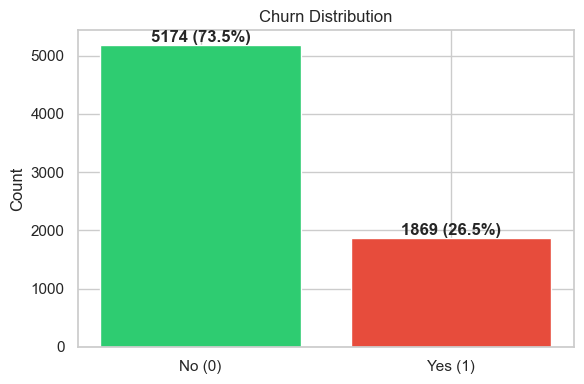

In [15]:
counts = df["Churn"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["No (0)", "Yes (1)"], counts.values, color=["#2ecc71", "#e74c3c"])
for bar, c in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, c + 50,
            f"{c} ({c / len(df) * 100:.1f}%)", ha="center", fontweight="bold")
ax.set_title("Churn Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 5. Numeric Features

In [16]:
num_cols = ["Tenure Months", "Monthly Charges", "Total Charges"]
df[num_cols].describe()

,Tenure Months,Monthly Charges,Total Charges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


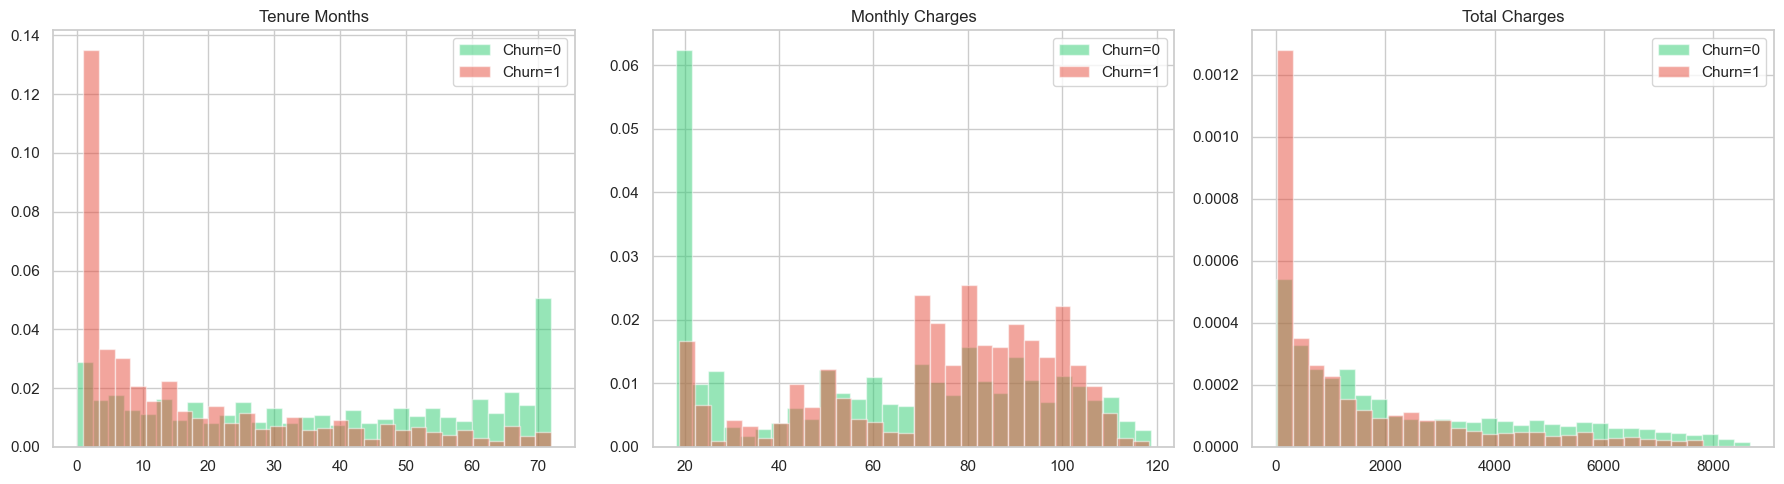

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    for label, color in [(0, "#2ecc71"), (1, "#e74c3c")]:
        subset = df.loc[df["Churn"] == label, col].dropna()
        ax.hist(subset, bins=30, alpha=0.5, color=color, label=f"Churn={label}", density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

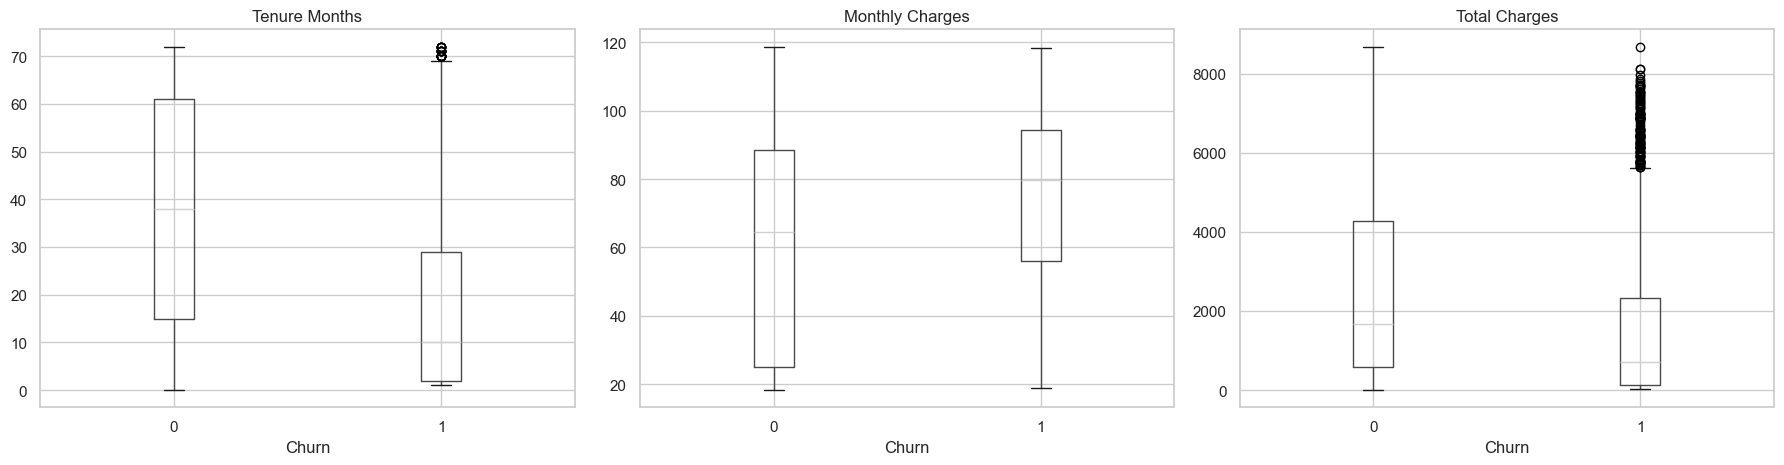

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by="Churn", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Churn")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [19]:
corr_with_churn = df[num_cols + ["Churn"]].corr()["Churn"].drop("Churn").sort_values(ascending=False)
print("Pearson correlation with Churn:")
print(corr_with_churn.to_frame("correlation"))

Pearson correlation with Churn:
                 correlation
Monthly Charges     0.193356
Total Charges      -0.198324
Tenure Months      -0.352229


## 6. Categorical Features

In [20]:
exclude_from_cat = {"City"}
cat_cols = [
    c for c in df.select_dtypes(include="object").columns
    if c not in exclude_from_cat
]
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

Categorical columns (16): ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [21]:
for col in cat_cols:
    vc = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({"count": vc, "pct": pct.round(2)})
    print(f"\n--- {col} ---")
    print(summary)


--- Gender ---
        count    pct
Gender              
Male     3555  50.48
Female   3488  49.52

--- Senior Citizen ---
                count    pct
Senior Citizen              
No               5901  83.79
Yes              1142  16.21

--- Partner ---
         count   pct
Partner             
No        3641  51.7
Yes       3402  48.3

--- Dependents ---
            count   pct
Dependents             
No           5416  76.9
Yes          1627  23.1

--- Phone Service ---
               count    pct
Phone Service              
Yes             6361  90.32
No               682   9.68

--- Multiple Lines ---
                  count    pct
Multiple Lines                
No                 3390  48.13
Yes                2971  42.18
No phone service    682   9.68

--- Internet Service ---
                  count    pct
Internet Service              
Fiber optic        3096  43.96
DSL                2421  34.37
No                 1526  21.67

--- Online Security ---
                     co

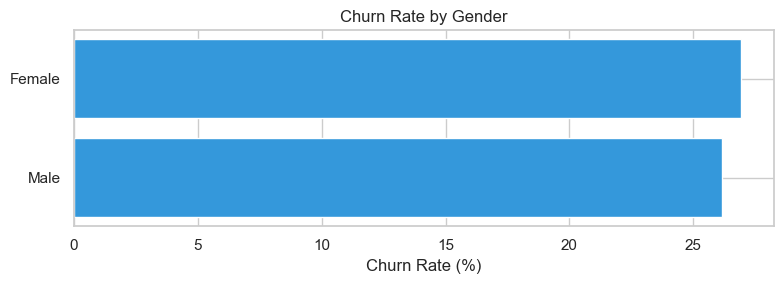

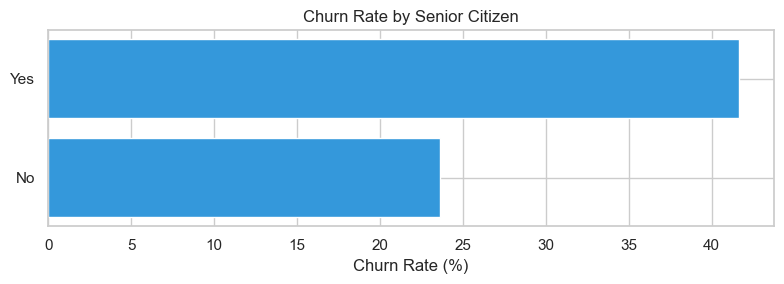

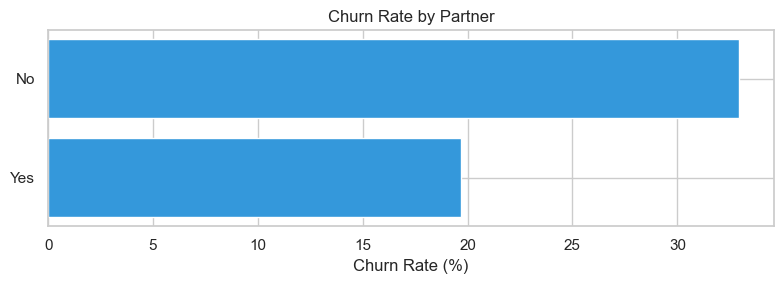

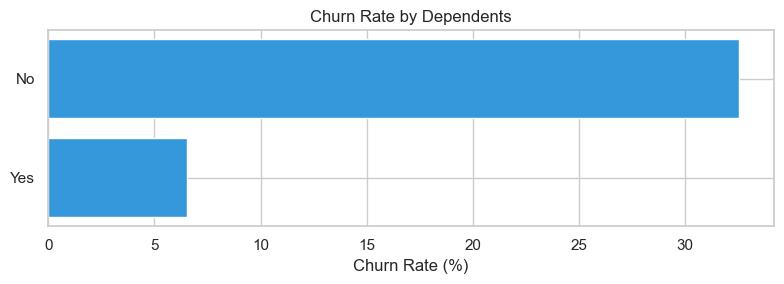

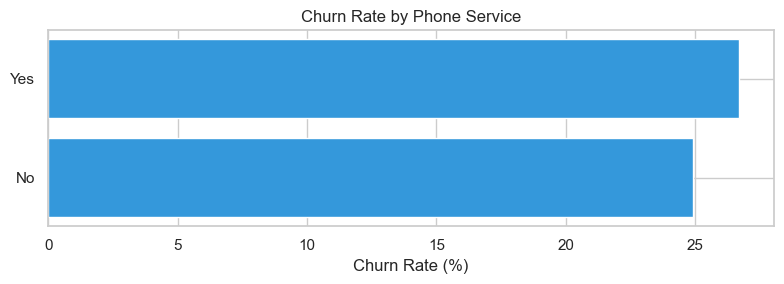

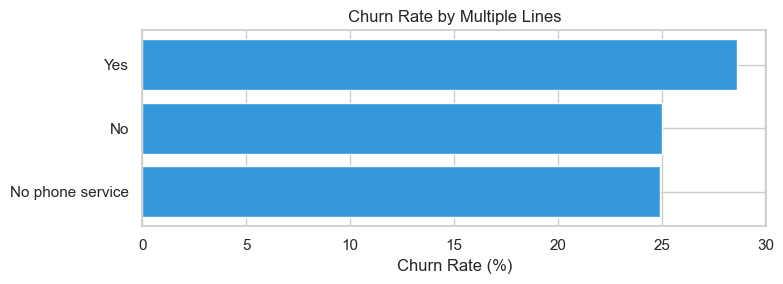

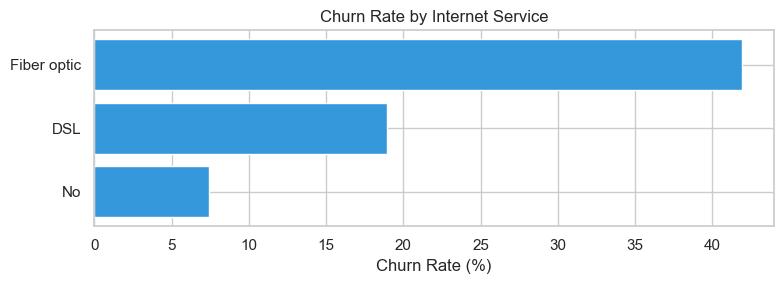

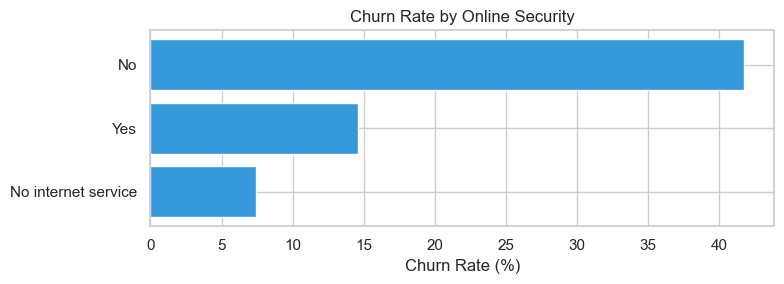

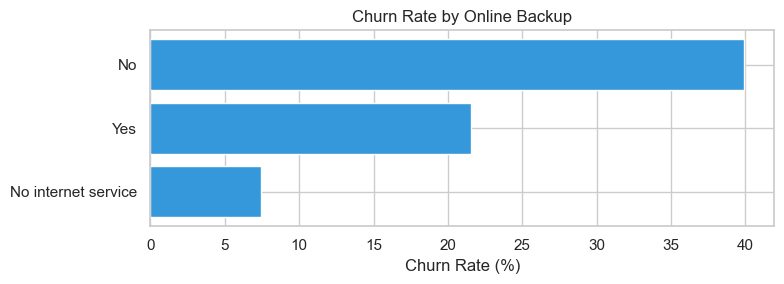

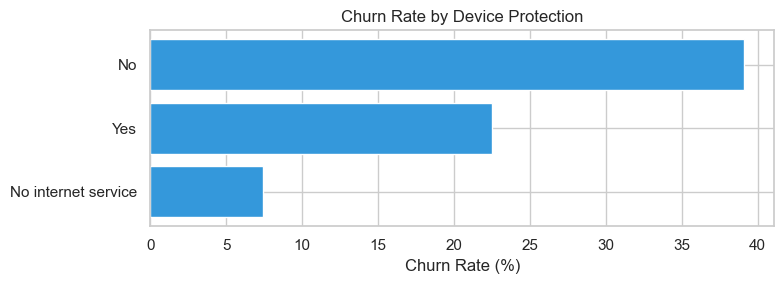

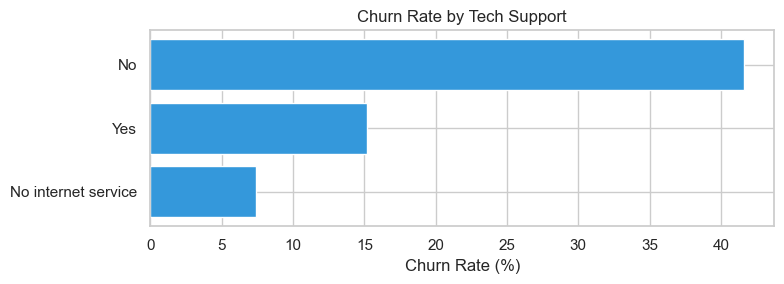

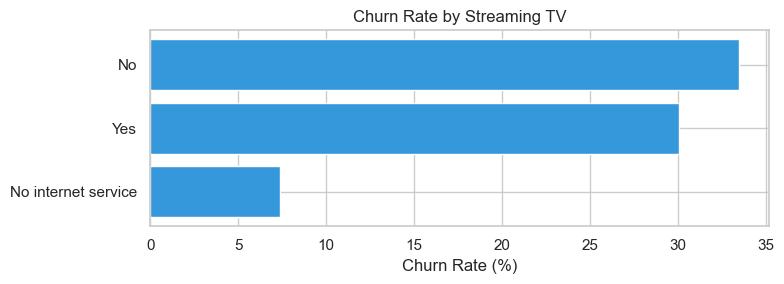

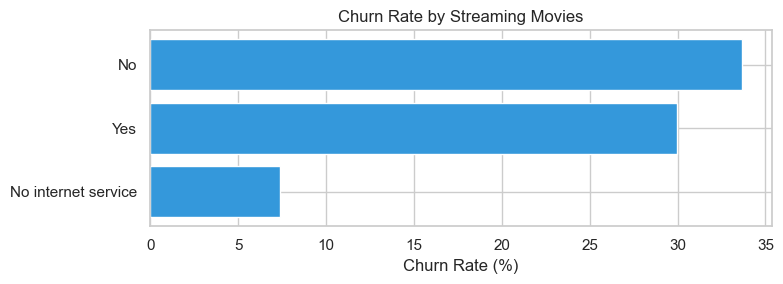

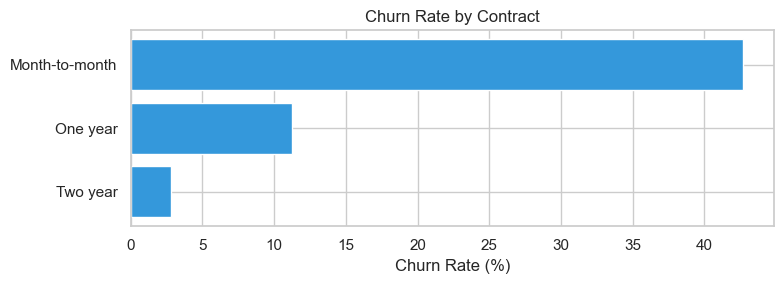

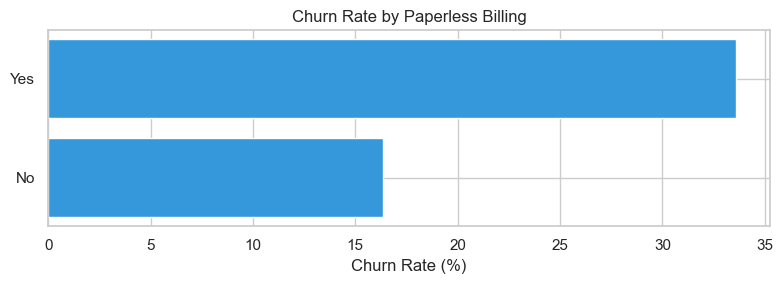

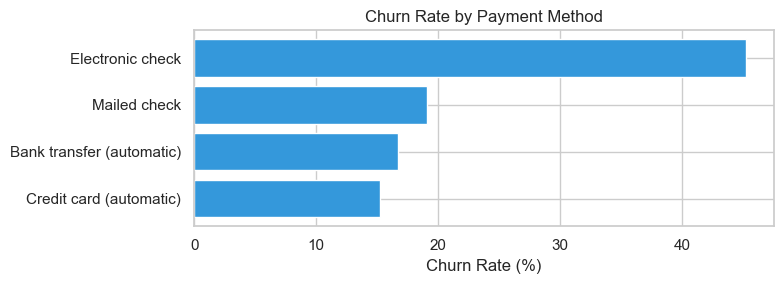

In [22]:
for col in cat_cols:
    rates = df.groupby(col)["Churn"].agg(["count", "mean"]).reset_index()
    rates.columns = [col, "count", "churn_rate"]
    rates["churn_rate_pct"] = (rates["churn_rate"] * 100).round(2)
    rates = rates.sort_values("churn_rate", ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(3, len(rates) * 0.5)))
    ax.barh(rates[col].astype(str), rates["churn_rate_pct"], color="#3498db")
    ax.set_xlabel("Churn Rate (%)")
    ax.set_title(f"Churn Rate by {col}")
    plt.tight_layout()
    plt.show()

## 7. Geographic Analysis

All 7,043 customers are in California. `State` was dropped (zero variance).
But `City` (1,129 unique) and `Latitude`/`Longitude` let us check for
geographic churn patterns within the state.

In [23]:
city_churn = (
    df.groupby("City")["Churn"]
    .agg(customers="count", churn_rate="mean")
    .reset_index()
    .assign(churn_rate_pct=lambda x: (x["churn_rate"] * 100).round(2))
    .sort_values("churn_rate", ascending=False)
)

print(f"Unique cities: {df['City'].nunique()}")
print(f"\nTop 10 cities by churn rate (min 20 customers):")
city_churn.query("customers >= 20").head(10)

Unique cities: 1129

Top 10 cities by churn rate (min 20 customers):


,City,customers,churn_rate,churn_rate_pct
908,Santa Rosa,24,0.458333,45.83
688,North Hollywood,20,0.450000,45.00
632,Modesto,28,0.428571,42.86
899,Santa Barbara,28,0.357143,35.71
869,San Diego,150,0.333333,33.33
371,Glendale,40,0.325000,32.50
1019,Torrance,25,0.320000,32.00
748,Pasadena,30,0.300000,30.00
872,San Francisco,104,0.298077,29.81
562,Los Angeles,305,0.295082,29.51


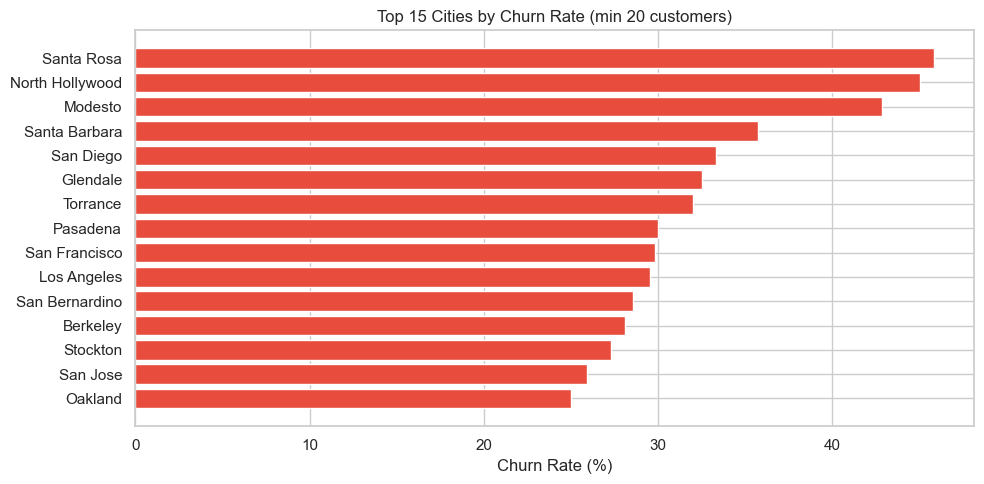

In [24]:
top_cities = city_churn.query("customers >= 20").head(15)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_cities["City"], top_cities["churn_rate_pct"], color="#e74c3c")
ax.set_xlabel("Churn Rate (%)")
ax.set_title("Top 15 Cities by Churn Rate (min 20 customers)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
print("Customers per city (top 10):")
print(df["City"].value_counts().head(10))

Customers per city (top 10):
City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
Fresno            64
Long Beach        60
Oakland           52
Stockton          44
Bakersfield       40
Name: count, dtype: int64


## 8. Key Insights & Multivariate Patterns

In [26]:
cross = (
    df.groupby(["Contract", "Internet Service"])["Churn"]
    .agg(count="count", churn_rate="mean")
    .reset_index()
    .assign(churn_rate_pct=lambda x: (x["churn_rate"] * 100).round(2))
    .sort_values("churn_rate", ascending=False)
)
cross

,Contract,Internet Service,count,churn_rate,churn_rate_pct
1,Month-to-month,Fiber optic,2128,0.546053,54.61
0,Month-to-month,DSL,1223,0.322159,32.22
4,One year,Fiber optic,539,0.192950,19.29
2,Month-to-month,No,524,0.188931,18.89
3,One year,DSL,570,0.092982,9.30
7,Two year,Fiber optic,429,0.072261,7.23
5,One year,No,364,0.024725,2.47
6,Two year,DSL,628,0.019108,1.91
8,Two year,No,638,0.007837,0.78


In [27]:
df["tenure_bucket"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12m", "13-24m", "25-48m", "49-72m"],
)

(
    df.groupby("tenure_bucket", observed=True)["Churn"]
    .agg(count="count", churn_rate="mean")
    .assign(churn_rate_pct=lambda x: (x["churn_rate"] * 100).round(2))
    .sort_values("churn_rate", ascending=False)
)

,count,churn_rate,churn_rate_pct
tenure_bucket,,,
0-12m,2186,0.474382,47.44
13-24m,1024,0.287109,28.71
25-48m,1594,0.203890,20.39
49-72m,2239,0.095132,9.51


In [28]:
df["charge_bucket"] = pd.cut(
    df["Monthly Charges"],
    bins=[0, 35, 70, 200],
    labels=["low", "medium", "high"],
)

(
    df.groupby("charge_bucket", observed=True)["Churn"]
    .agg(count="count", churn_rate="mean")
    .assign(churn_rate_pct=lambda x: (x["churn_rate"] * 100).round(2))
    .sort_values("churn_rate", ascending=False)
)

,count,churn_rate,churn_rate_pct
charge_bucket,,,
high,3583,0.353614,35.36
medium,1725,0.239420,23.94
low,1735,0.108934,10.89


In [29]:
cross_pay = (
    df.groupby(["Payment Method", "Contract"])["Churn"]
    .agg(count="count", churn_rate="mean")
    .reset_index()
    .assign(churn_rate_pct=lambda x: (x["churn_rate"] * 100).round(2))
    .sort_values("churn_rate", ascending=False)
)
cross_pay

,Payment Method,Contract,count,churn_rate,churn_rate_pct
6,Electronic check,Month-to-month,1850,0.537297,53.73
0,Bank transfer (automatic),Month-to-month,589,0.341256,34.13
3,Credit card (automatic),Month-to-month,543,0.327808,32.78
9,Mailed check,Month-to-month,893,0.315789,31.58
7,Electronic check,One year,347,0.184438,18.44
4,Credit card (automatic),One year,398,0.103015,10.30
1,Bank transfer (automatic),One year,391,0.097187,9.72
8,Electronic check,Two year,168,0.077381,7.74
10,Mailed check,One year,337,0.068249,6.82
2,Bank transfer (automatic),Two year,564,0.033688,3.37


In [30]:
service_cols = [
    "Phone Service", "Multiple Lines", "Internet Service",
    "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies",
]

df["n_services"] = sum(
    df[c].isin(["Yes", "DSL", "Fiber optic"]).astype(int)
    for c in service_cols
)

(
    df.groupby("n_services")["Churn"]
    .agg(count="count", churn_rate="mean")
    .assign(churn_rate_pct=lambda x: (x["churn_rate"] * 100).round(2))
)

,count,churn_rate,churn_rate_pct
n_services,,,
1,1264,0.109177,10.92
2,859,0.309662,30.97
3,846,0.449173,44.92
4,965,0.364767,36.48
5,922,0.313449,31.34
6,908,0.255507,25.55
7,676,0.224852,22.49
8,395,0.124051,12.41
9,208,0.052885,5.29


## 9. Outlier Detection (IQR)

In [31]:
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    mask = (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)
    n_outliers = mask.sum()
    print(f"{col}: {n_outliers} outliers ({n_outliers / len(df) * 100:.1f}%)")

Tenure Months: 0 outliers (0.0%)
Monthly Charges: 0 outliers (0.0%)
Total Charges: 0 outliers (0.0%)


## 10. Correlation Heatmap

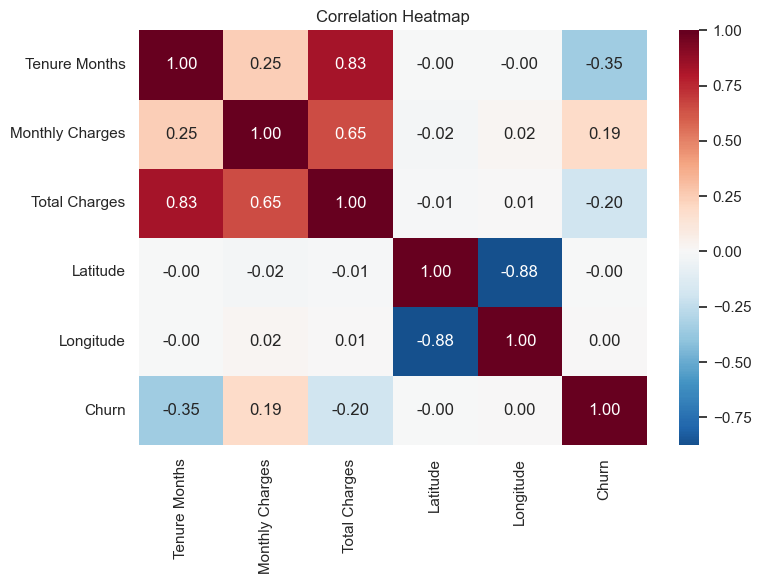

In [32]:
corr_cols = ["Tenure Months", "Monthly Charges", "Total Charges", "Latitude", "Longitude", "Churn"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 11. Data Readiness Summary

Key questions answered:
1. **Strongest predictors**: Contract type, Internet Service, Tenure Months, Payment Method
2. **Class imbalance**: ~2.8:1 ratio -- moderate, will need `class_weight` or `pos_weight` in loss
3. **Data quality**: 11 nulls in Total Charges (new customers) -- filled with 0
4. **Feature engineering ideas**: `n_services` count, `tenure_bucket`, `charge_bucket`
5. **Preprocessing plan**: OneHotEncoder for categoricals, StandardScaler for numericals
6. **Geographic**: All customers in California; City has 1,129 values (too granular for modeling, drop)

In [33]:
temp_cols = ["tenure_bucket", "charge_bucket", "n_services"]
eda_only_cols = ["City", "Latitude", "Longitude"]
usable_cols = [c for c in df.columns if c not in temp_cols + eda_only_cols + ["Churn"]]

print("=" * 60)
print("DATA READINESS SUMMARY")
print("=" * 60)
print(f"Source dataset:         Extended IBM Telco (33 cols, California)")
print(f"After column triage:    {df.shape[0]:,} rows x {len(usable_cols)} usable features")
print(f"Dropped columns:        {len(drop_cols)} (ID, zero-var, leakage)")
print(f"EDA-only columns:       {len(eda_only_cols)} ({', '.join(eda_only_cols)})")
print(f"Numeric features:       {len(num_cols)} ({', '.join(num_cols)})")
print(f"Categorical features:   {len(cat_cols)}")
print(f"Target (Churn):         {df['Churn'].sum()} churned ({df['Churn'].mean():.2%})")
print(f"Missing values:         {df[usable_cols].isnull().sum().sum()}")
print()
print("COLUMNS DROPPED (leakage / zero-variance / ID):")
for c in drop_cols:
    print(f"  - {c}")
print()
print("COLUMNS FOR EDA ONLY (not for modeling):")
for c in eda_only_cols:
    print(f"  - {c}")

DATA READINESS SUMMARY
Source dataset:         Extended IBM Telco (33 cols, California)
After column triage:    7,043 rows x 19 usable features
Dropped columns:        10 (ID, zero-var, leakage)
EDA-only columns:       3 (City, Latitude, Longitude)
Numeric features:       3 (Tenure Months, Monthly Charges, Total Charges)
Categorical features:   16
Target (Churn):         1869 churned (26.54%)
Missing values:         0

COLUMNS DROPPED (leakage / zero-variance / ID):
  - CustomerID
  - Count
  - Country
  - State
  - Zip Code
  - Lat Long
  - Churn Value
  - Churn Score
  - CLTV
  - Churn Reason

COLUMNS FOR EDA ONLY (not for modeling):
  - City
  - Latitude
  - Longitude


In [34]:
df.drop(columns=temp_cols, inplace=True)

## 12. Export Cleaned Data

Save the cleaned DataFrame to `data/processed/` as **Parquet** so that other team members
can start modeling directly without repeating the triage and cleaning steps above.

Why Parquet over CSV:
- Preserves column dtypes (float64, int64, object) -- no re-casting needed on read
- Columnar compression -- smaller file size
- Standard format for ML pipelines (MLflow, Spark, scikit-learn)

Before saving, column names are normalized to **snake_case** for consistency with the Python ecosystem.

In [36]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

DATA_PROCESSED = Path("..") / "data" / "processed"
if not (Path("..") / "data").exists():
    DATA_PROCESSED = Path("data") / "processed"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

output_path = DATA_PROCESSED / "telco_churn_clean.parquet"
df.to_parquet(output_path, index=False)

print(f"Saved {df.shape[0]:,} rows x {df.shape[1]} columns -> {output_path}")
print(f"Columns: {list(df.columns)}")
print(f"\nDtypes:\n{df.dtypes}")

Saved 7,043 rows x 23 columns -> ../data/processed/telco_churn_clean.parquet
Columns: ['city', 'latitude', 'longitude', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn']

Dtypes:
city                  object
latitude             float64
longitude            float64
gender                object
senior_citizen        object
partner               object
dependents            object
tenure_months          int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing  